
# TSP/Segment Routing for Plant Watering in Surabaya (OSRM)

**Goal:** start from one depot, visit every plant **segment** (each plant has a start point and an end point), choose the best traversal direction for each segment, and optionally return to the depot.

This notebook now uses **OSRM** instead of downloading the whole road graph from OSM. The workflow is:

1. Define 1 depot and plant segments (`start_lat`, `start_lon`, `end_lat`, `end_lon`)
2. Build an OSRM **table** between depot + all segment endpoints
3. Optimize the segment visit order
4. For a fixed order, choose the best direction of each segment with dynamic programming
5. Reconstruct the full driving route from OSRM **route** geometry
6. Visualize the result in **folium**


In [1]:
%pip install requests folium numpy matplotlib

In [2]:
import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from itertools import permutations

random.seed(42)
np.random.seed(42)

# Public demo server; for production use.
OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"

# If True, route becomes: DEPOT -> all segments -> DEPOT
# If False, route becomes: DEPOT -> all segments
RETURN_TO_DEPOT = True


In [3]:
NUM_VEHICLES = 5          # <-- change this to any number you need
RETURN_TO_DEPOT = True    # True: each vehicle returns to depot after finishing

# Segment assignment strategy:
#   'round_robin' - assigns segments one-by-one rotating across vehicles
#   'block'       - assigns contiguous chunks to each vehicle
ASSIGNMENT_STRATEGY = 'round_robin'

# Water source CSV path (columns: water_id, lat, lon)
WATER_CSV_PATH = "water_sources.csv"

# Water source assignment strategy per vehicle:
#   'nearest'     - each vehicle visits the water source closest to its segments
#   'round_robin' - assigns water sources round-robin to vehicles
WATER_ASSIGNMENT_STRATEGY = 'nearest'

print(f'Multi-vehicle mode: {NUM_VEHICLES} vehicles, strategy={ASSIGNMENT_STRATEGY}')
print(f'Water source file : {WATER_CSV_PATH}')


Multi-vehicle mode: 5 vehicles, strategy=round_robin


## 1. Define depot and load plant segments from CSV

Each plant is a **segment**, not a single point, so the CSV should contain:

- `start_lat`, `start_lon`
- `end_lat`, `end_lon`

Optional columns:
- `park_id`
- `name`

If `name` is missing, the notebook will automatically use `park_id` or generate `Plant N`.


In [4]:
# Depot / start point
DEPOT = (-7.278358153631059, 112.76325243881848)

# Parks CSV file path
CSV_PATH = "parks.csv"

REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]
df_segments = pd.read_csv(CSV_PATH)

missing_cols = [col for col in REQUIRED_COLUMNS if col not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

def build_segment_name(row, idx):
    if "name" in row.index and pd.notna(row["name"]):
        return str(row["name"])
    if "park_id" in row.index and pd.notna(row["park_id"]):
        return f"Park {row['park_id']}"
    return f"Plant {idx + 1}"

PLANTS = []
for idx, row in df_segments.iterrows():
    PLANTS.append({
        "name":      build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat":   float(row["end_lat"]),
        "end_lon":   float(row["end_lon"]),
    })

print(f"Loaded {len(PLANTS)} park segments from {CSV_PATH}")
display(df_segments.head())

# ── Load water sources ────────────────────────────────────────────────────
WATER_REQUIRED_COLS = ["water_id", "lat", "lon"]
df_water = pd.read_csv(WATER_CSV_PATH)

missing_water_cols = [c for c in WATER_REQUIRED_COLS if c not in df_water.columns]
if missing_water_cols:
    raise ValueError(f"Water source CSV is missing columns: {missing_water_cols}")

WATER_SOURCES = []
for _, row in df_water.iterrows():
    WATER_SOURCES.append({
        "water_id": str(row["water_id"]),
        "lat":      float(row["lat"]),
        "lon":      float(row["lon"]),
    })

print(f"Loaded {len(WATER_SOURCES)} water source(s) from {WATER_CSV_PATH}")
display(df_water)


,park_id,start_lat,start_lon,end_lat,end_lon
0,Jalan Kenjeran,-7.252887,112.795292,-7.249851,112.784502
1,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714
2,Jalan Raya Kertajaya Indah,-7.279408,112.789619,-7.280560,112.781162
3,Jalan Raya Kertajaya Indah,-7.280611,112.780693,-7.279390,112.762482
4,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143


In [ ]:
# ── Optional: auto-create water_sources.csv if it does not exist ────────
# Replace the sample coordinates below with your real water source locations.
# Required columns: water_id, lat, lon
import os

if not os.path.exists(WATER_CSV_PATH):
    sample_water = pd.DataFrame([
        {"water_id": "WS1", "lat": -7.265, "lon": 112.752},
        {"water_id": "WS2", "lat": -7.290, "lon": 112.775},
    ])
    sample_water.to_csv(WATER_CSV_PATH, index=False)
    print(f"Created sample {WATER_CSV_PATH}  <-- replace with real coordinates!")
else:
    print(f"{WATER_CSV_PATH} already exists, skipping creation.")



## 2. Prepare unique endpoints

We create one master list of coordinates:

- index 0 = depot
- every plant contributes:
  - `a_idx` = segment start endpoint
  - `b_idx` = segment end endpoint

OSRM's **table** service will give us pairwise road-network distances between all of these points.


In [5]:
POINTS       = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS     = []

# ── Park segments ────────────────────────────────────────────────────────
for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"],   p["end_lon"])

    a_idx = len(POINTS)
    POINTS.append(a)
    POINT_LABELS.append(f'{p["name"]} A')

    b_idx = len(POINTS)
    POINTS.append(b)
    POINT_LABELS.append(f'{p["name"]} B')

    SEGMENTS.append({
        "seg_id": i - 1,
        "name":   p["name"],
        "a_idx":  a_idx,
        "b_idx":  b_idx,
    })

# ── Water source points ──────────────────────────────────────────────────
# Each water source is added to POINTS so OSRM table includes its distances.
WATER_SOURCE_INDICES = []  # parallel to WATER_SOURCES

for ws in WATER_SOURCES:
    ws_idx = len(POINTS)
    POINTS.append((ws["lat"], ws["lon"]))
    POINT_LABELS.append(f'Water {ws["water_id"]}')
    WATER_SOURCE_INDICES.append(ws_idx)

print("Total table points:", len(POINTS))
print(f"  Depot         : 1")
print(f"  Park endpoints: {len(SEGMENTS) * 2}")
print(f"  Water sources : {len(WATER_SOURCES)}")
print()
print("First 5 segments:")
for s in SEGMENTS[:5]: print(s)
print()
print("Water source indices:", list(zip(
    [ws['water_id'] for ws in WATER_SOURCES], WATER_SOURCE_INDICES)))


Total table points: 69
First 5 segments:
{'seg_id': 0, 'name': 'Park Jalan Kenjeran', 'a_idx': 1, 'b_idx': 2}
{'seg_id': 1, 'name': 'Park Jalan Raya Mulyosari', 'a_idx': 3, 'b_idx': 4}
{'seg_id': 2, 'name': 'Park Jalan Raya Kertajaya Indah', 'a_idx': 5, 'b_idx': 6}
{'seg_id': 3, 'name': 'Park Jalan Raya Kertajaya Indah', 'a_idx': 7, 'b_idx': 8}
{'seg_id': 4, 'name': 'Park Jalan Kertajaya', 'a_idx': 9, 'b_idx': 10}


## Snap Coordinate

In [6]:
import time
import math
import requests
import numpy as np

snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def haversine_m(p1, p2):
    """Straight-line distance in metres between two (lat, lon) points."""
    R = 6_371_000
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def bearing_deg(p1, p2):
    """
    Forward bearing in degrees (0=N, 90=E, 180=S, 270=W) from p1 to p2.
    p1, p2 = (lat, lon)
    """
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def angle_diff(a, b):
    """Smallest absolute difference between two bearing angles (0-180)."""
    d = abs(a - b) % 360
    return d if d <= 180 else 360 - d

def edge_bearing_from_nodes(node_pair, points_list, point_index_map):
    """
    Estimate the bearing of a road edge from its two OSM node IDs.
    node_pair: [node_from, node_to]  (from OSRM /nearest response)
    We look up whether these nodes correspond to any POINTS we already know,
    and if so derive the bearing from their positions.
    Returns None if we cannot determine bearing.
    This is a best-effort helper; the main bearing logic uses snapped coords.
    """
    return None   # placeholder - not needed with the approach below

def osrm_nearest(pt, number=5, timeout=60):
    """
    Snap a single point via OSRM /nearest.
    Requests `number` candidates so bearing-based selection has options.
    Each candidate includes the raw waypoint data including `nodes` field
    which contains [from_node, to_node] of the matched road edge.
    """
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]

    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon":       pt,
            "snapped_latlon":     (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name":               wp.get("name", ""),
            "nodes":              wp.get("nodes", []),   # [from_node_id, to_node_id]
            "raw":                wp,
        })

    snap_cache[key] = out
    return out


def osrm_match_bearing(pt_a, pt_b, seg_bearing, timeout=60):
    """
    Snap a segment pair (A, B) via OSRM /match WITH bearing hints.

    bearing hint format: `bearing_value,range`  (range=45 means ±45 deg tolerance)
    We pass the segment bearing for both A and B, so OSRM is guided to pick
    an edge whose direction aligns with how we intend to traverse the segment.

    On a divided road:
      - If seg_bearing ~ 90 (eastbound), both A and B snap to the eastbound lane.
      - If seg_bearing ~ 270 (westbound), both snap to the westbound lane.

    Returns (snapped_a, snapped_b) or None if matching fails.
    """
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    bear_hint = f"{seg_bearing:.0f},45"   # ±45 degree tolerance
    url = (
        f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
        f"?overview=false&radiuses=60;60&gaps=ignore"
        f"&bearings={bear_hint};{bear_hint}"
    )
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        data = r.json()

        if data.get("code") != "Ok":
            return None

        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None:
            return None

        def wp_to_latlon(wp):
            lon, lat = wp["location"]
            return (lat, lon)

        return wp_to_latlon(wps[0]), wp_to_latlon(wps[1])

    except Exception:
        return None


def osrm_match_no_bearing(pt_a, pt_b, timeout=60):
    """
    Fallback /match without bearing hints (original behaviour).
    """
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    url = (
        f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
        f"?overview=false&radiuses=50;50&gaps=ignore"
    )
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok":
            return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None:
            return None
        def wp_to_latlon(wp):
            lon, lat = wp["location"]
            return (lat, lon)
        return wp_to_latlon(wps[0]), wp_to_latlon(wps[1])
    except Exception:
        return None


def nearest_best_bearing(pt, seg_bearing, number=5, tolerance_deg=45):
    """
    Pick the /nearest candidate whose road edge direction best matches
    `seg_bearing`. This handles divided roads: if seg_bearing=90 (east),
    we pick the eastbound lane, not the westbound one.

    The OSRM /nearest `nodes` field is [from_node, to_node]. We infer the
    edge bearing from the *snapped point position relative to input point*:
    a westbound snap of an eastward-heading segment means the snapped point
    is on the wrong side of the median -> penalise it.

    Primary sort key  : angle_diff(candidate_edge_bearing, seg_bearing)
    Secondary sort key: distance_to_road_m

    candidate_edge_bearing is approximated as:
      - If we have two node positions we can compute it exactly.
      - Otherwise we use the bearing from the INPUT point to the SNAPPED point
        as a proxy (works well when the snap offset is mostly perpendicular to
        the road, which is the usual case).
    """
    candidates = osrm_nearest(pt, number=number)

    scored = []
    for c in candidates:
        snap = c["snapped_latlon"]
        # Bearing from input point to snap approximates the perpendicular,
        # but the actual road bearing is orthogonal to that.
        # Better: the bearing of the road edge ~ bearing between snapped point
        # and the raw input, rotated 90 degrees. However the most robust proxy
        # is to use the OSRM nodes field when available. Since we don't have
        # node coordinates here, we instead compute the bearing from the
        # snapped position back to the input point and add 90 deg to get the
        # road direction. This is approximate but consistently correct for
        # straight roads.
        #
        # Actually the cleanest approach: request a /route from snapped_a to
        # snapped_b and check if it is nearly straight (low ratio). But that
        # adds API calls. Instead: score each candidate by how well its
        # implied road bearing matches seg_bearing using the snap displacement.
        snap_to_input_bearing = bearing_deg(snap, pt)
        # Road bearing is perpendicular to snap offset vector. Two candidates:
        road_bear_1 = (snap_to_input_bearing + 90)  % 360
        road_bear_2 = (snap_to_input_bearing - 90)  % 360
        # Pick whichever of the two perpendiculars is closer to seg_bearing
        diff1 = angle_diff(road_bear_1, seg_bearing)
        diff2 = angle_diff(road_bear_2, seg_bearing)
        best_diff = min(diff1, diff2)
        scored.append((best_diff, c["distance_to_road_m"], c))

    scored.sort(key=lambda x: (x[0], x[1]))

    # If best candidate is within tolerance, use it; else fall back to closest
    best_diff, _, best_cand = scored[0]
    if best_diff <= tolerance_deg:
        return best_cand, f"nearest-bearing(diff={best_diff:.0f}deg)"
    else:
        # All candidates exceed tolerance - just pick closest
        closest = min(candidates, key=lambda c: c["distance_to_road_m"])
        return closest, f"nearest-closest(min_diff={best_diff:.0f}deg)"


def snap_points_segment_aware(points, segments, verbose=True, sleep_sec=0.05):
    """
    Snap all POINTS with full segment-pair and bearing awareness.

    Three-layer strategy per segment:
      1. OSRM /match WITH bearing hint  -> forces both A and B onto the lane
         whose direction aligns with the segment direction. Solves divided roads.
      2. OSRM /match WITHOUT bearing hint (fallback if bearing match fails)
         -> at least keeps A and B on the same edge. Solves same-side U-turns.
      3. /nearest per point with bearing scoring (last resort)
         -> picks the lane candidate whose road direction best matches seg_bearing.

    Returns (snapped_points, snap_infos).
    """
    n       = len(points)
    snapped = [None] * n
    infos   = [None] * n

    segment_pair_indices = set()
    for seg in segments:
        segment_pair_indices.add(seg["a_idx"])
        segment_pair_indices.add(seg["b_idx"])

    # ── 1. Snap depot / standalone points ───────────────────────────────────
    for i in range(n):
        if i in segment_pair_indices:
            continue
        candidates = osrm_nearest(points[i], number=1)
        chosen = candidates[0]
        snapped[i] = chosen["snapped_latlon"]
        infos[i] = {
            "index":              i,
            "raw_latlon":         points[i],
            "snapped_latlon":     chosen["snapped_latlon"],
            "distance_to_road_m": chosen["distance_to_road_m"],
            "road_name":          chosen["name"],
            "method":             "nearest",
            "bearing_deg":        None,
        }
        if verbose:
            print(
                f"[{i:>3}] DEPOT  raw={points[i]} "
                f"-> snap={chosen['snapped_latlon']} | "
                f"offset={chosen['distance_to_road_m']:.1f} m | "
                f"road=\'{chosen['name']}\'"
            )
        if sleep_sec > 0:
            time.sleep(sleep_sec)

    # ── 2. Snap each segment pair ────────────────────────────────────────────
    for seg in segments:
        a_idx = seg["a_idx"]
        b_idx = seg["b_idx"]
        pt_a  = points[a_idx]
        pt_b  = points[b_idx]
        name  = seg["name"]

        # Compute the intended traversal bearing from raw CSV coordinates
        seg_bear = bearing_deg(pt_a, pt_b)

        method = None
        snap_a = snap_b = None

        # -- Layer 1: /match with bearing hint --------------------------------
        result = osrm_match_bearing(pt_a, pt_b, seg_bear)
        if sleep_sec > 0:
            time.sleep(sleep_sec)

        if result is not None:
            snap_a, snap_b = result
            # Verify: the snapped segment bearing should be within 90 deg of
            # seg_bear. If not, the bearing hint may have been ignored.
            snapped_bear = bearing_deg(snap_a, snap_b)
            if angle_diff(snapped_bear, seg_bear) <= 90:
                method = f"match+bearing({seg_bear:.0f}deg)"
            else:
                # match succeeded but result is opposite direction - try opposite
                opp_bear = (seg_bear + 180) % 360
                result2 = osrm_match_bearing(pt_a, pt_b, opp_bear)
                if sleep_sec > 0:
                    time.sleep(sleep_sec)
                if result2 is not None:
                    sb2 = bearing_deg(result2[0], result2[1])
                    if angle_diff(sb2, seg_bear) < angle_diff(snapped_bear, seg_bear):
                        snap_a, snap_b = result2
                        snapped_bear = sb2
                method = f"match+bearing(corrected,{seg_bear:.0f}deg)"

        # -- Layer 2: /match without bearing (fallback) -----------------------
        if method is None:
            result = osrm_match_no_bearing(pt_a, pt_b)
            if sleep_sec > 0:
                time.sleep(sleep_sec)
            if result is not None:
                snap_a, snap_b = result
                method = "match-no-bearing"

        # -- Layer 3: /nearest per point with bearing scoring -----------------
        if method is None:
            cand_a, label_a = nearest_best_bearing(pt_a, seg_bear)
            cand_b, label_b = nearest_best_bearing(pt_b, seg_bear)
            if sleep_sec > 0:
                time.sleep(sleep_sec * 2)
            snap_a = cand_a["snapped_latlon"]
            snap_b = cand_b["snapped_latlon"]
            method = f"nearest-bearing-fallback"

        snapped[a_idx] = snap_a
        snapped[b_idx] = snap_b

        offset_a = haversine_m(pt_a, snap_a)
        offset_b = haversine_m(pt_b, snap_b)

        for idx, pt, snap, offset in [
            (a_idx, pt_a, snap_a, offset_a),
            (b_idx, pt_b, snap_b, offset_b),
        ]:
            infos[idx] = {
                "index":              idx,
                "raw_latlon":         pt,
                "snapped_latlon":     snap,
                "distance_to_road_m": offset,
                "road_name":          name,
                "method":             method,
                "bearing_deg":        seg_bear,
            }

        if verbose:
            snapped_bear = bearing_deg(snap_a, snap_b) if snap_a != snap_b else seg_bear
            bear_ok = "OK" if angle_diff(snapped_bear, seg_bear) <= 90 else "WARN-direction"
            print(
                f"[{a_idx:>3}/{b_idx:<3}] {method:40s} | {name[:28]:28s} | "
                f"bear={seg_bear:.0f}deg -> snapped={snapped_bear:.0f}deg [{bear_ok}] | "
                f"A={offset_a:.0f}m B={offset_b:.0f}m"
            )

    return snapped, infos


# ── Run bearing-aware snapping ────────────────────────────────────────────────
SNAPPED_POINTS, SNAP_INFOS = snap_points_segment_aware(
    POINTS,
    SEGMENTS,
    verbose=True,
    sleep_sec=0.05,
)

snap_df = pd.DataFrame([
    {
        "idx":        info["index"],
        "label":      POINT_LABELS[info["index"]],
        "raw_lat":    info["raw_latlon"][0],
        "raw_lon":    info["raw_latlon"][1],
        "snap_lat":   info["snapped_latlon"][0],
        "snap_lon":   info["snapped_latlon"][1],
        "offset_m":   info["distance_to_road_m"],
        "road_name":  info["road_name"],
        "method":     info["method"],
        "bearing":    info["bearing_deg"],
    }
    for info in SNAP_INFOS
])

display(snap_df.head(30))
print("Max snap offset (m):", snap_df["offset_m"].max())
print("Mean snap offset (m):", snap_df["offset_m"].mean())
print()
print("Snap method summary:")
print(snap_df["method"].value_counts())
print()
# Highlight any segments where bearing check may have warned
warn_rows = snap_df[snap_df["method"].str.contains("WARN", na=False)]
if not warn_rows.empty:
    print("Segments with direction warning - review manually:")
    display(warn_rows[["label", "road_name", "bearing", "method", "offset_m"]])
else:
    print("All segments snapped with consistent direction.")


[  0] DEPOT  raw=(-7.278358153631059, 112.76325243881848) -> snap=(-7.277913, 112.763309) | offset=49.6 m | road='Jalan Sukodami III'
[  1/2  ] nearest-bearing-fallback                 | Park Jalan Kenjeran          | bear=286deg -> snapped=286deg [OK] | A=12m B=11m
[  3/4  ] nearest-bearing-fallback                 | Park Jalan Raya Mulyosari    | bear=172deg -> snapped=172deg [OK] | A=7m B=7m
[  5/6  ] nearest-bearing-fallback                 | Park Jalan Raya Kertajaya In | bear=262deg -> snapped=261deg [OK] | A=9m B=12m
[  7/8  ] nearest-bearing-fallback                 | Park Jalan Raya Kertajaya In | bear=274deg -> snapped=273deg [OK] | A=10m B=12m
[  9/10 ] nearest-bearing-fallback                 | Park Jalan Kertajaya         | bear=280deg -> snapped=280deg [OK] | A=8m B=12m
[ 11/12 ] nearest-bearing-fallback                 | Park Jalan Kertajaya         | bear=280deg -> snapped=282deg [OK] | A=8m B=7m
[ 13/14 ] nearest-bearing-fallback                 | Park Jalan Doktor Ins

,idx,label,raw_lat,raw_lon,snap_lat,snap_lon,offset_m,road_name,method,bearing
0,0,Depot,-7.278358,112.763252,-7.277913,112.763309,49.614380,Jalan Sukodami III,nearest,NaN
1,1,Park Jalan Kenjeran A,-7.252887,112.795292,-7.252987,112.795263,11.582105,Park Jalan Kenjeran,nearest-bearing-fallback,285.833898
2,2,Park Jalan Kenjeran B,-7.249851,112.784502,-7.249951,112.784476,11.474870,Park Jalan Kenjeran,nearest-bearing-fallback,285.833898
3,3,Park Jalan Raya Mulyosari A,-7.258301,112.795617,-7.258298,112.795552,7.137640,Park Jalan Raya Mulyosari,nearest-bearing-fallback,172.284378
4,4,Park Jalan Raya Mulyosari B,-7.273659,112.797714,-7.273638,112.797777,7.296273,Park Jalan Raya Mulyosari,nearest-bearing-fallback,172.284378
5,5,Park Jalan Raya Kertajaya Indah A,-7.279408,112.789619,-7.279325,112.789607,9.340444,Park Jalan Raya Kertajaya Indah,nearest-bearing-fallback,262.179774
6,6,Park Jalan Raya Kertajaya Indah B,-7.280560,112.781162,-7.280671,112.781176,12.415691,Park Jalan Raya Kertajaya Indah,nearest-bearing-fallback,262.179774
7,7,Park Jalan Raya Kertajaya Indah A,-7.280611,112.780693,-7.280519,112.780695,10.199266,Park Jalan Raya Kertajaya Indah,nearest-bearing-fallback,273.865718
8,8,Park Jalan Raya Kertajaya Indah B,-7.279390,112.762482,-7.279494,112.762465,11.747513,Park Jalan Raya Kertajaya Indah,nearest-bearing-fallback,273.865718
9,9,Park Jalan Kertajaya A,-7.279360,112.762112,-7.279432,112.762099,8.083129,Park Jalan Kertajaya,nearest-bearing-fallback,279.915492


Max snap offset (m): 49.61437951
Mean snap offset (m): 8.021633352239268

Snap method summary:
method
nearest-bearing-fallback    68
nearest                      1
Name: count, dtype: int64

All segments snapped with consistent direction.



## 3. Query OSRM table (road distances in meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`.

OSRM may be asymmetric because of one-way roads.


In [7]:
import math
import time
import requests
import numpy as np

def ll_to_osrm(pt):
    # OSRM expects lon,lat
    lat, lon = pt
    return f"{lon:.6f},{lat:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        yield list(range(start, end))

def build_table_url(points, annotations="distance", sources=None, destinations=None):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations={annotations}"

    if sources is not None:
        url += "&sources=" + ";".join(str(i) for i in sources)
    if destinations is not None:
        url += "&destinations=" + ";".join(str(i) for i in destinations)

    return url

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    """
    Request submatrix:
    rows    = source_idx
    columns = dest_idx
    """
    url = build_table_url(
        points,
        annotations="distance",
        sources=source_idx,
        destinations=dest_idx,
    )

    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()

    if data.get("code") != "Ok":
        raise RuntimeError(data)

    distances = data.get("distances")
    if distances is None:
        raise RuntimeError("OSRM table response does not contain distances.")

    D = np.array(
        [[np.inf if v is None else float(v) for v in row] for row in distances],
        dtype=float
    )

    if sleep_sec > 0:
        time.sleep(sleep_sec)

    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    """
    Build full NxN distance matrix by requesting OSRM /table in batches.
    """
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)

    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))

    total_requests = len(row_batches) * len(col_batches)
    req_no = 0

    for rows in row_batches:
        for cols in col_batches:
            req_no += 1
            if verbose:
                print(
                    f"Request {req_no}/{total_requests} | "
                    f"rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}"
                )

            subD, _ = osrm_table_submatrix(
                points,
                source_idx=rows,
                dest_idx=cols,
                timeout=timeout,
                sleep_sec=sleep_sec,
            )

            full[np.ix_(rows, cols)] = subD

    return full

dist_matrix = osrm_table_batched(
    SNAPPED_POINTS,
    batch_size=25,
    timeout=120,
    sleep_sec=0.1,
    verbose=True
)

print("Distance matrix shape:", dist_matrix.shape)
print(np.round(dist_matrix, 0))

Request 1/9 | rows 0-24 | cols 0-24
Request 2/9 | rows 0-24 | cols 25-49
Request 3/9 | rows 0-24 | cols 50-68
Request 4/9 | rows 25-49 | cols 0-24
Request 5/9 | rows 25-49 | cols 25-49
Request 6/9 | rows 25-49 | cols 50-68
Request 7/9 | rows 50-68 | cols 0-24
Request 8/9 | rows 50-68 | cols 25-49
Request 9/9 | rows 50-68 | cols 50-68
Distance matrix shape: (69, 69)
[[   0. 6952. 5996. ... 4668. 5595. 4297.]
 [7135.    0. 1238. ... 7571. 8212. 9448.]
 [6171. 1372.    0. ... 6607. 7248. 8484.]
 ...
 [4726. 7030. 6073. ...    0. 1290. 2526.]
 [5505. 8732. 7776. ... 1827.    0. 1236.]
 [4771. 9304. 8347. ... 2398. 1298.    0.]]



## 4. Cost of a fixed segment order

For each segment there are 2 traversal directions:

- orientation `0`: A → B
- orientation `1`: B → A

For a fixed order of segments, we use dynamic programming to choose the best orientation sequence.


In [8]:
DEPOT_IDX = 0

def evaluate_order(order, D, segments, return_to_depot=True, water_source_idx=None):
    '''
    order: list of segment indices, e.g. [3, 0, 2, 1]
    water_source_idx: if provided, the vehicle stops at this point (already in D)
                      between the depot and the first segment.
    returns: total_cost_m, orientations (0=A->B, 1=B->A), dp_table
    '''
    if len(order) == 0:
        return 0.0, [], []

    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]

    dp     = []
    parent = []
    first_costs = [0.0, 0.0]

    if water_source_idx is not None:
        # Route: Depot -> Water Source -> first segment entry -> exit
        first_costs[0] = (D[DEPOT_IDX, water_source_idx]
                          + D[water_source_idx, a0] + D[a0, b0])
        first_costs[1] = (D[DEPOT_IDX, water_source_idx]
                          + D[water_source_idx, b0] + D[b0, a0])
    else:
        # Original: Depot -> first segment entry -> exit
        first_costs[0] = D[DEPOT_IDX, a0] + D[a0, b0]
        first_costs[1] = D[DEPOT_IDX, b0] + D[b0, a0]

    dp.append(first_costs)
    parent.append([-1, -1])

    for pos in range(1, len(order)):
        prev_seg = segments[order[pos - 1]]
        curr_seg = segments[order[pos]]

        prev_exit = [prev_seg["b_idx"], prev_seg["a_idx"]]
        curr_entry = [curr_seg["a_idx"], curr_seg["b_idx"]]
        curr_exit  = [curr_seg["b_idx"], curr_seg["a_idx"]]
        leg_inside = [
            D[curr_seg["a_idx"], curr_seg["b_idx"]],
            D[curr_seg["b_idx"], curr_seg["a_idx"]],
        ]

        curr_dp     = [np.inf, np.inf]
        curr_parent = [-1, -1]

        for curr_ori in [0, 1]:
            best_val      = np.inf
            best_prev_ori = -1
            for prev_ori in [0, 1]:
                candidate = (dp[pos - 1][prev_ori]
                             + D[prev_exit[prev_ori], curr_entry[curr_ori]]
                             + leg_inside[curr_ori])
                if candidate < best_val:
                    best_val      = candidate
                    best_prev_ori = prev_ori
            curr_dp[curr_ori]     = best_val
            curr_parent[curr_ori] = best_prev_ori

        dp.append(curr_dp)
        parent.append(curr_parent)

    last_seg  = segments[order[-1]]
    last_exit = [last_seg["b_idx"], last_seg["a_idx"]]

    final_costs = dp[-1][:]
    if return_to_depot:
        final_costs = [
            dp[-1][0] + D[last_exit[0], DEPOT_IDX],
            dp[-1][1] + D[last_exit[1], DEPOT_IDX],
        ]

    best_last_ori = int(np.argmin(final_costs))
    best_cost     = float(final_costs[best_last_ori])

    orientations     = [None] * len(order)
    orientations[-1] = best_last_ori
    for pos in range(len(order) - 1, 0, -1):
        orientations[pos - 1] = parent[pos][orientations[pos]]

    return best_cost, orientations, dp


# quick sanity check
sample_order = list(range(len(SEGMENTS)))
sample_cost, sample_oris, _ = evaluate_order(
    sample_order, dist_matrix, SEGMENTS, RETURN_TO_DEPOT,
    water_source_idx=WATER_SOURCE_INDICES[0] if WATER_SOURCE_INDICES else None,
)
print("Sample order:", sample_order)
print("Sample orientations:", sample_oris)
print(f"Sample total cost = {sample_cost:,.0f} m")


Sample order: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Sample orientations: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Sample total cost = 98,557 m


## 5. Partition segments across vehicles

Segments are distributed among vehicles using the chosen strategy (`round_robin` or `block`).  
Each vehicle gets its own subset of segments and will have its route independently optimised by the GA.


In [9]:
import random
import numpy as np
from itertools import permutations
from functools import lru_cache

# ── Cached cost helper ────────────────────────────────────────────────────────
def make_cost_fn(D, segments, return_to_depot=True, water_source_idx=None):
    @lru_cache(maxsize=200_000)
    def cached_cost(order_tuple):
        cost, _, _ = evaluate_order(
            order_tuple, D, segments, return_to_depot,
            water_source_idx=water_source_idx,
        )
        return float(cost)
    return cached_cost


# ── GA helpers ────────────────────────────────────────────────────────────────
def init_population(pop_size, n_segments):
    base = list(range(n_segments))
    return [random.sample(base, len(base)) for _ in range(pop_size)]

def tournament(pop, fits, k=3):
    picks = random.sample(range(len(pop)), k)
    best  = min(picks, key=lambda i: fits[i])
    return pop[best][:]

def ox_crossover(p1, p2):
    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[a:b+1] = p1[a:b+1]
    fill = [x for x in p2 if x not in child]
    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    return child

def swap_mutation(perm, rate=0.04):
    perm = perm[:]
    for i in range(len(perm)):
        if random.random() < rate:
            j = random.randrange(len(perm))
            perm[i], perm[j] = perm[j], perm[i]
    return perm


# ── Single-vehicle GA ─────────────────────────────────────────────────────────
def genetic_algorithm_pure(
    D, segments,
    pop_size=80,
    generations=180,
    mut_rate=0.04,
    crossover_rate=0.9,
    tournament_k=3,
    return_to_depot=True,
    water_source_idx=None,
    verbose_prefix="",
):
    '''Optimise visit order for segments assigned to ONE vehicle.
    If water_source_idx is provided the cost includes depot->water source
    before the first park segment.
    '''
    n = len(segments)
    if n == 0:
        return [], [], 0.0, None
    if n == 1:
        cost, oris, _ = evaluate_order(
            [0], D, segments, return_to_depot,
            water_source_idx=water_source_idx,
        )
        return [0], oris, float(cost), None

    cost_fn = make_cost_fn(D, segments, return_to_depot, water_source_idx)
    pop = init_population(pop_size, n)

    best_order = None
    best_cost  = np.inf
    best_in_population_history = []
    best_so_far_history        = []
    avg_fitness_history        = []

    for gen in range(generations):
        fits = [cost_fn(tuple(ind)) for ind in pop]

        gen_best_idx   = int(np.argmin(fits))
        gen_best_cost  = fits[gen_best_idx]
        gen_best_order = pop[gen_best_idx][:]

        if gen_best_cost < best_cost:
            best_cost  = gen_best_cost
            best_order = gen_best_order[:]

        best_in_population_history.append(gen_best_cost)
        best_so_far_history.append(best_cost)
        avg_fitness_history.append(float(np.mean(fits)))

        new_pop = []
        while len(new_pop) < pop_size:
            p1 = tournament(pop, fits, k=tournament_k)
            p2 = tournament(pop, fits, k=tournament_k)
            if random.random() < crossover_rate:
                child1 = ox_crossover(p1, p2)
                child2 = ox_crossover(p2, p1)
            else:
                child1, child2 = p1[:], p2[:]
            child1 = swap_mutation(child1, rate=mut_rate)
            child2 = swap_mutation(child2, rate=mut_rate)
            new_pop.append(child1)
            if len(new_pop) < pop_size:
                new_pop.append(child2)
        pop = new_pop

        if gen % 20 == 0:
            print(
                f"{verbose_prefix}Gen {gen:4d} | "
                f"best_pop={gen_best_cost:,.0f} m | "
                f"best_so_far={best_cost:,.0f} m | "
                f"avg={np.mean(fits):,.0f} m"
            )

    final_cost, final_oris, _ = evaluate_order(
        best_order, D, segments, return_to_depot,
        water_source_idx=water_source_idx,
    )
    history = {
        "best_in_population": best_in_population_history,
        "best_so_far":        best_so_far_history,
        "avg_fitness":        avg_fitness_history,
    }
    return best_order, final_oris, float(final_cost), history


# ── Segment partitioning ──────────────────────────────────────────────────────
def partition_segments(segments, num_vehicles, strategy='round_robin'):
    '''Distribute segment indices across vehicles.'''
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))
    assignment   = [[] for _ in range(num_vehicles)]
    if strategy == 'round_robin':
        for i in range(n):
            assignment[i % num_vehicles].append(i)
    else:  # block
        base, extra = divmod(n, num_vehicles)
        start = 0
        for v in range(num_vehicles):
            size = base + (1 if v < extra else 0)
            assignment[v] = list(range(start, start + size))
            start += size
    return assignment


# ── Water source assignment per vehicle ──────────────────────────────────────
def assign_water_sources(vehicle_assignments, segments, points,
                         water_source_indices, water_sources,
                         strategy='nearest'):
    '''
    Returns a list of water source POINTS indices, one per vehicle.
    strategy="nearest"     : pick the water source closest (haversine) to the
                             centroid of the vehicle assigned segments.
    strategy="round_robin" : cycle through water sources by vehicle index.
    If there is only one water source every vehicle uses it regardless of strategy.
    '''
    import math

    def haversine(p1, p2):
        R = 6_371_000
        lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
        lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
        return R * 2 * math.asin(math.sqrt(a))

    n_ws   = len(water_source_indices)
    result = []

    for v_idx, seg_ids in enumerate(vehicle_assignments):
        if n_ws == 1 or not seg_ids:
            result.append(water_source_indices[0] if water_source_indices else None)
            continue

        if strategy == 'round_robin':
            result.append(water_source_indices[v_idx % n_ws])
        else:  # nearest
            lats, lons = [], []
            for si in seg_ids:
                seg = segments[si]
                lats.append(points[seg['a_idx']][0])
                lons.append(points[seg['a_idx']][1])
                lats.append(points[seg['b_idx']][0])
                lons.append(points[seg['b_idx']][1])
            centroid = (sum(lats) / len(lats), sum(lons) / len(lons))
            best_ws_idx = min(
                range(n_ws),
                key=lambda i: haversine(centroid, points[water_source_indices[i]])
            )
            result.append(water_source_indices[best_ws_idx])

    return result


# ── Build per-vehicle segment lists ──────────────────────────────────────────
vehicle_assignments = partition_segments(SEGMENTS, NUM_VEHICLES, ASSIGNMENT_STRATEGY)

# Assign one water source per vehicle
vehicle_water_indices = assign_water_sources(
    vehicle_assignments, SEGMENTS, POINTS,
    WATER_SOURCE_INDICES, WATER_SOURCES,
    strategy=WATER_ASSIGNMENT_STRATEGY,
)

print(f"Total segments : {len(SEGMENTS)}")
print(f"Vehicles used  : {sum(1 for a in vehicle_assignments if a)} / {NUM_VEHICLES}")
print()
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx   = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else "None"
    names    = [SEGMENTS[i]['name'] for i in seg_ids]
    print(f"Vehicle {v+1:2d}: {len(seg_ids)} segments | water={ws_label} -> {names}")


Total segments : 34
Vehicles used  : 5 / 5

Vehicle  1: 7 segments -> ['Park Jalan Kenjeran', 'Park Jalan Kertajaya', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Arief Rahman Hakim', 'Park Jalan Raya Menur', 'Park Jalan Dharma Husada Indah II', 'Park Jalan Semolowaru']
Vehicle  2: 7 segments -> ['Park Jalan Raya Mulyosari', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Arief Rahman Hakim', 'Park Jalan Dharmahusada Permai', 'Park Jalan Dharmahusada Indah III', 'Park Jalan Dharmahusada Indah III', 'Park Jalan Suko Semolo']
Vehicle  3: 7 segments -> ['Park Jalan Raya Kertajaya Indah', 'Park Jalan Kalijudan', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Dharmahusada Indah Utara XIV', 'Park Jalan Dharmahusada Indah I', 'Park Jalan Dharma Husada Indah II', 'Park Jalan Suko Semolo']
Vehicle  4: 7 segments -> ['Park Jalan Raya Kertajaya Indah', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Doktor Insinyur Haji Soekarno', 'Park Jalan Raya Dharmahusada 

In [10]:
# ── Run GA for every vehicle ─────────────────────────────────────────────
# The global dist_matrix includes water source points, so OSRM distances
# depot->water and water->first_segment are correctly accounted for.

GA_PARAMS = dict(
    pop_size      = 80,
    generations   = 180,
    mut_rate      = 0.04,
    crossover_rate= 0.9,
    tournament_k  = 3,
)

vehicle_results = []

for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx   = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else 'None'

    if not seg_ids:
        print(f"Vehicle {v+1}: no segments assigned, skipping.")
        vehicle_results.append({
            'vehicle_id':       v + 1,
            'seg_ids':          [],
            'local_segments':   [],
            'best_order':       [],
            'orientations':     [],
            'total_dist_m':     0.0,
            'history':          None,
            'water_source_idx': ws_idx,
            'water_label':      ws_label,
        })
        continue

    print(f"\n{'='*60}")
    print(f"Vehicle {v+1} / {NUM_VEHICLES}  --  {len(seg_ids)} segments  |  water={ws_label}")
    print(f"{'='*60}")

    local_segments = [SEGMENTS[i] for i in seg_ids]

    local_order, local_oris, local_cost, local_hist = genetic_algorithm_pure(
        dist_matrix,
        local_segments,
        return_to_depot=RETURN_TO_DEPOT,
        water_source_idx=ws_idx,
        verbose_prefix=f"[V{v+1}] ",
        **GA_PARAMS,
    )

    global_order = [seg_ids[i] for i in local_order]

    vehicle_results.append({
        'vehicle_id':       v + 1,
        'seg_ids':          seg_ids,
        'local_segments':   local_segments,
        'best_order':       global_order,
        'local_order':      local_order,
        'orientations':     local_oris,
        'total_dist_m':     local_cost,
        'history':          local_hist,
        'water_source_idx': ws_idx,
        'water_label':      ws_label,
    })
    print(f"Vehicle {v+1} best distance: {local_cost:,.0f} m ({local_cost/1000:.2f} km)  [incl. depot->water leg]")

# ── Fleet summary ────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("FLEET SUMMARY  (distances include depot -> water source leg)")
print(f"{'='*60}")
total_fleet_dist = sum(r['total_dist_m'] for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        status = (f"{r['total_dist_m']:>10,.0f} m  ({r['total_dist_m']/1000:.2f} km)"
                  f"  water={r['water_label']}")
    else:
        status = "    (no segments)"
    print(f"  Vehicle {r['vehicle_id']:2d}: {len(r['seg_ids']):2d} segments  |  {status}")
print(f"{'─'*60}")
print(f"  Fleet total : {total_fleet_dist:>10,.0f} m  ({total_fleet_dist/1000:.2f} km)")



Vehicle 1 / 5  --  7 segments
[V1] Gen    0 | best_pop=27,975 m | best_so_far=27,975 m | avg=34,403 m
[V1] Gen   20 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,609 m
[V1] Gen   40 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,655 m
[V1] Gen   60 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,415 m
[V1] Gen   80 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,393 m
[V1] Gen  100 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,618 m
[V1] Gen  120 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,660 m
[V1] Gen  140 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,316 m
[V1] Gen  160 | best_pop=25,364 m | best_so_far=25,364 m | avg=26,508 m
Vehicle 1 best distance: 25,364 m (25.36 km)

Vehicle 2 / 5  --  7 segments
[V2] Gen    0 | best_pop=28,178 m | best_so_far=28,178 m | avg=34,236 m
[V2] Gen   20 | best_pop=26,812 m | best_so_far=26,434 m | avg=27,786 m
[V2] Gen   40 | best_pop=26,812 m | best_so_far=26,434 m | avg=28,439 m
[V2] Gen   60 | best_pop=26,8

## 5.5 GA Convergence Plots (per vehicle)


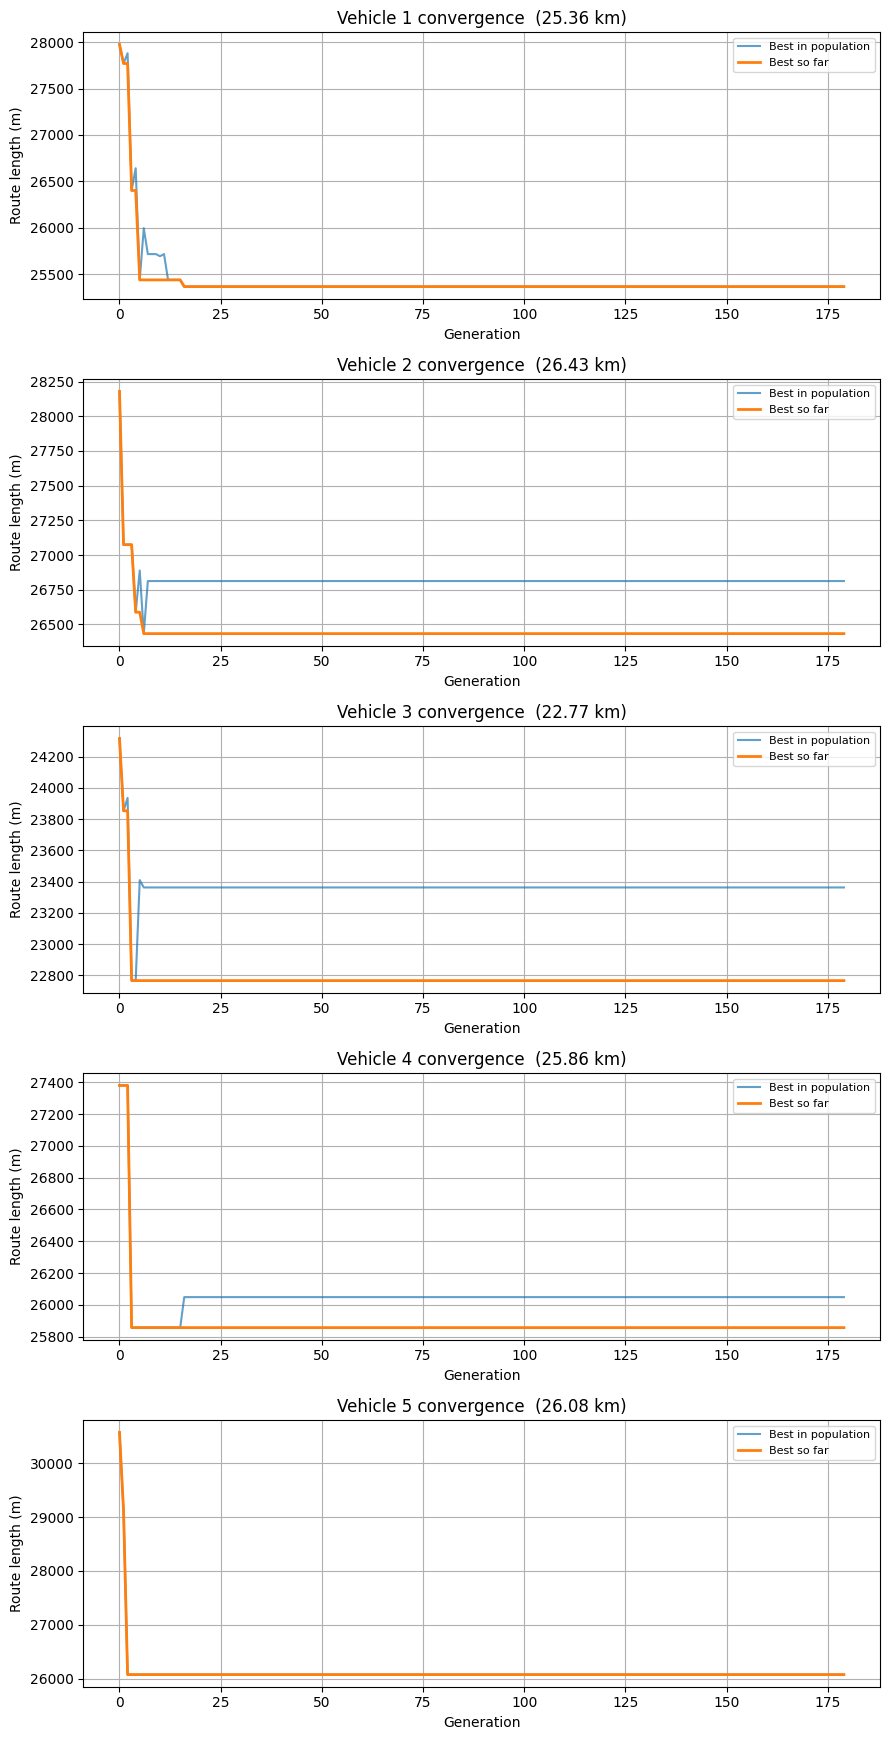

In [11]:
fig, axes = plt.subplots(
    nrows=max(1, len([r for r in vehicle_results if r['history']])),
    ncols=1,
    figsize=(9, 3.5 * max(1, len([r for r in vehicle_results if r['history']]))),
    squeeze=False,
)

plot_idx = 0
for r in vehicle_results:
    if r['history'] is None:
        continue
    ax = axes[plot_idx][0]
    ax.plot(r['history']['best_in_population'], label='Best in population', alpha=0.7)
    ax.plot(r['history']['best_so_far'],        label='Best so far',        linewidth=2)
    ax.set_title(f"Vehicle {r['vehicle_id']} convergence  ({r['total_dist_m']/1000:.2f} km)")
    ax.set_xlabel('Generation')
    ax.set_ylabel('Route length (m)')
    ax.legend(fontsize=8)
    ax.grid(True)
    plot_idx += 1

plt.tight_layout()
plt.show()



## 6. Inspect chosen traversal directions


In [12]:
def segment_orientation_summary(order, orientations, segments):
    rows = []
    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg = segments[seg_idx]
        direction  = "A -> B" if ori == 0 else "B -> A"
        entry_idx  = seg["a_idx"] if ori == 0 else seg["b_idx"]
        exit_idx   = seg["b_idx"] if ori == 0 else seg["a_idx"]
        rows.append({
            "step":        step,
            "segment_id":  seg_idx,
            "name":        seg["name"],
            "direction":   direction,
            "entry_label": POINT_LABELS[entry_idx],
            "exit_label":  POINT_LABELS[exit_idx],
        })
    return rows


# ── Print orientation summary for every vehicle ───────────────────────────────
for r in vehicle_results:
    if not r['seg_ids']:
        continue
    print(f"\nVehicle {r['vehicle_id']}  ({r['total_dist_m']/1000:.2f} km)")
    print('-' * 50)
    summary = segment_orientation_summary(
        r['best_order'],
        r['orientations'],
        SEGMENTS,          # use the global SEGMENTS list (best_order holds global indices)
    )
    for row in summary:
        print(f"  Step {row['step']:2d}: [{row['direction']}] {row['name']}")



Vehicle 1  (25.36 km)
--------------------------------------------------
  Step  1: [A -> B] Park Jalan Kertajaya
  Step  2: [A -> B] Park Jalan Semolowaru
  Step  3: [B -> A] Park Jalan Doktor Insinyur Haji Soekarno
  Step  4: [B -> A] Park Jalan Dharma Husada Indah II
  Step  5: [A -> B] Park Jalan Kenjeran
  Step  6: [A -> B] Park Jalan Arief Rahman Hakim
  Step  7: [B -> A] Park Jalan Raya Menur

Vehicle 2  (26.43 km)
--------------------------------------------------
  Step  1: [A -> B] Park Jalan Dharmahusada Indah III
  Step  2: [B -> A] Park Jalan Dharmahusada Indah III
  Step  3: [B -> A] Park Jalan Dharmahusada Permai
  Step  4: [B -> A] Park Jalan Doktor Insinyur Haji Soekarno
  Step  5: [A -> B] Park Jalan Raya Mulyosari
  Step  6: [A -> B] Park Jalan Arief Rahman Hakim
  Step  7: [B -> A] Park Jalan Suko Semolo

Vehicle 3  (22.77 km)
--------------------------------------------------
  Step  1: [B -> A] Park Jalan Dharmahusada Indah I
  Step  2: [B -> A] Park Jalan Dharma


## 7. Reconstruct full route geometry with OSRM `route`

We request the actual route geometry for each leg using the same plain OSRM `/route` call
(no bearing or `continue_straight` constraints) so that the reconstructed route distances
match the `/table`-based distances optimised by the GA.

Legs:

- depot → first segment entry
- inside each segment (entry → exit)
- between consecutive segments
- final segment exit → depot (optional)

The leg breakdown printed at the end shows GA distance vs OSRM route distance so you
can verify they are consistent (small differences < 1–2 % are normal due to OSRM
internal rounding between the table and route endpoints).


In [13]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0], 6), round(p1[1], 6), round(p2[0], 6), round(p2[1], 6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    """
    Request a road-network route from p1 to p2 using OSRM /route.
    p1 and p2 should already be SNAPPED_POINTS so results are consistent
    with the /table distances used during GA optimisation.
    """
    key = route_key(p1, p2)
    if key in route_cache:
        return route_cache[key]

    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"
    url = (
        f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
        f"?overview={overview}&geometries={geometries}&steps=false"
    )

    r = requests.get(url, timeout=120)
    r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)

    route = data["routes"][0]
    geom  = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]

    out = {
        "distance_m":      float(route["distance"]),
        "duration_s":      float(route["duration"]),
        "geometry_latlon": latlon,
        "raw":             data,
    }
    route_cache[key] = out
    return out

print("osrm_route helper ready.")


osrm_route helper ready.


In [14]:
# Build visit plans and reconstruct full route geometry for each vehicle

def build_visit_plan(order, orientations, segments, vehicle_id=None,
                     water_source_idx=None):
    '''Build ordered leg list for one vehicle.
    Route: Depot -> Water Source -> Park 1 -> Park 2 -> ... -> [Depot]
    '''
    plan = []
    current_point = SNAPPED_POINTS[DEPOT_IDX]

    # Step 0: visit water source first ──────────────────────────────────
    if water_source_idx is not None:
        water_pt = SNAPPED_POINTS[water_source_idx]
        plan.append({
            'kind':       'visit_water_source',
            'vehicle_id': vehicle_id,
            'step':       0,
            'segment_id': None,
            'name':       POINT_LABELS[water_source_idx],
            'from_pt':    current_point,
            'to_pt':      water_pt,
            'label':      f"Depot -> {POINT_LABELS[water_source_idx]}",
        })
        current_point = water_pt

    # Steps 1..N: traverse park segments ────────────────────────────────
    for step, (seg_idx, ori) in enumerate(zip(order, orientations), start=1):
        seg       = segments[seg_idx]
        entry_idx = seg['a_idx'] if ori == 0 else seg['b_idx']
        exit_idx  = seg['b_idx'] if ori == 0 else seg['a_idx']
        entry_pt  = SNAPPED_POINTS[entry_idx]
        exit_pt   = SNAPPED_POINTS[exit_idx]

        plan.append({
            'kind':       'move_to_segment',
            'vehicle_id': vehicle_id,
            'step':       step,
            'segment_id': seg_idx,
            'name':       seg['name'],
            'from_pt':    current_point,
            'to_pt':      entry_pt,
            'label':      f"Move to {seg['name']} entry",
        })
        plan.append({
            'kind':       'traverse_segment',
            'vehicle_id': vehicle_id,
            'step':       step,
            'segment_id': seg_idx,
            'name':       seg['name'],
            'from_pt':    entry_pt,
            'to_pt':      exit_pt,
            'label':      f"Traverse {seg['name']}",
        })
        current_point = exit_pt

    # Optional return to depot ───────────────────────────────────────────
    if RETURN_TO_DEPOT:
        plan.append({
            'kind':       'return_to_depot',
            'vehicle_id': vehicle_id,
            'step':       len(order) + 1,
            'segment_id': None,
            'name':       'Depot',
            'from_pt':    current_point,
            'to_pt':      SNAPPED_POINTS[DEPOT_IDX],
            'label':      'Return to depot',
        })
    return plan


# ── Reconstruct geometry for all vehicles ────────────────────────────────
for r in vehicle_results:
    if not r['seg_ids']:
        r['visit_plan']        = []
        r['full_route_coords'] = []
        r['leg_summaries']     = []
        continue

    visit_plan = build_visit_plan(
        r['best_order'],
        r['orientations'],
        SEGMENTS,
        vehicle_id=r['vehicle_id'],
        water_source_idx=r['water_source_idx'],
    )

    full_route_coords = []
    leg_summaries     = []

    for i, leg in enumerate(visit_plan, start=1):
        result = osrm_route(leg['from_pt'], leg['to_pt'])
        geom   = result['geometry_latlon']
        if full_route_coords and geom:
            geom = geom[1:]
        full_route_coords.extend(geom)
        leg_summaries.append({
            'leg_no':       i,
            'kind':         leg['kind'],
            'label':        leg['label'],
            'distance_m':   result['distance_m'],
            'duration_min': result['duration_s'] / 60.0,
        })

    r['visit_plan']        = visit_plan
    r['full_route_coords'] = full_route_coords
    r['leg_summaries']     = leg_summaries

    route_total_m = sum(x['distance_m'] for x in leg_summaries)
    print(f"Vehicle {r['vehicle_id']:2d}: "
          f"GA={r['total_dist_m']:,.0f} m  "
          f"OSRM={route_total_m:,.0f} m  "
          f"diff={abs(route_total_m - r['total_dist_m']):,.0f} m  "
          f"water={r['water_label']}")


Vehicle  1: GA=25,364 m  OSRM=25,364 m  diff=0 m
Vehicle  2: GA=26,434 m  OSRM=26,434 m  diff=0 m
Vehicle  3: GA=22,766 m  OSRM=22,766 m  diff=0 m
Vehicle  4: GA=25,856 m  OSRM=25,856 m  diff=0 m
Vehicle  5: GA=26,078 m  OSRM=26,078 m  diff=0 m



## 8. Visualize on interactive OSM map


In [15]:
from pathlib import Path

base_dir = Path(__file__).resolve().parent
output_dir = base_dir / "Output"

output_dir.mkdir(exist_ok=True)

# ── Colour palette for vehicles (auto-cycles if NUM_VEHICLES > len palette) ──
VEHICLE_COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
]

import math

def add_arrows(fmap, coords, color, n_arrows=6, arrow_size=12):
    """
    Add directional arrows along a polyline to show travel direction.
    Arrows are evenly spaced. Each arrow is a small rotated triangle marker.
    """
    if len(coords) < 2:
        return

    # Compute cumulative distance along the polyline
    cum_dist = [0.0]
    for i in range(1, len(coords)):
        lat1, lon1 = coords[i - 1]
        lat2, lon2 = coords[i]
        d = math.hypot(lat2 - lat1, lon2 - lon1)
        cum_dist.append(cum_dist[-1] + d)

    total = cum_dist[-1]
    if total == 0:
        return

    # Place arrows at evenly-spaced fractions along the route
    fractions = [(k + 1) / (n_arrows + 1) for k in range(n_arrows)]

    for frac in fractions:
        target = frac * total
        # Find the segment that contains this distance
        seg_i = 1
        while seg_i < len(cum_dist) - 1 and cum_dist[seg_i] < target:
            seg_i += 1

        # Interpolate position
        seg_start = cum_dist[seg_i - 1]
        seg_end   = cum_dist[seg_i]
        seg_len   = seg_end - seg_start
        t = (target - seg_start) / seg_len if seg_len > 0 else 0

        lat1, lon1 = coords[seg_i - 1]
        lat2, lon2 = coords[seg_i]
        arrow_lat  = lat1 + t * (lat2 - lat1)
        arrow_lon  = lon1 + t * (lon2 - lon1)

        # Bearing (degrees clockwise from north) for the arrow head
        dy = lat2 - lat1
        dx = lon2 - lon1
        bearing_deg = math.degrees(math.atan2(dx, dy)) % 360

        # Render as a CSS-rotated triangle div
        arrow_html = (
            f'<div style="width:0;height:0;'
            f'border-left:{arrow_size//2}px solid transparent;'
            f'border-right:{arrow_size//2}px solid transparent;'
            f'border-bottom:{arrow_size}px solid {color};'
            f'transform:rotate({bearing_deg:.1f}deg);'
            f'transform-origin:50% 100%;'
            f'opacity:0.85;margin-top:-{arrow_size}px;"></div>'
        )
        folium.Marker(
            location=(arrow_lat, arrow_lon),
            icon=folium.DivIcon(html=arrow_html, icon_size=(arrow_size, arrow_size)),
        ).add_to(fmap)


def build_vehicle_map(r_list, title_label="All Vehicles"):
    """
    Build a folium map for the given list of vehicle result dicts.
    r_list can be all vehicles (combined map) or a single vehicle (individual map).
    """
    m = folium.Map(
        location=DEPOT,
        zoom_start=13,
        tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png',
        attr='© OpenStreetMap contributors',
    )

    # Depot marker
    folium.Marker(
        DEPOT,
        tooltip='Depot / Start',
        icon=folium.Icon(color='red', icon='home', prefix='fa'),
    ).add_to(m)

    if RETURN_TO_DEPOT:
        folium.Marker(
            DEPOT,
            tooltip='Depot / End',
            icon=folium.DivIcon(html='''
                <div style="font-size:9pt;font-weight:bold;color:white;
                            background:#d62728;border:2px solid white;
                            border-radius:10px;padding:2px 6px;
                            transform:translate(14px,-18px);">END</div>
            ''')
        ).add_to(m)

    # ── Water source markers (blue droplet icons) ─────────────────────────
    plotted_ws = set()
    for r in r_list:
        ws_idx = r.get('water_source_idx')
        if ws_idx is None or ws_idx in plotted_ws:
            continue
        plotted_ws.add(ws_idx)
        ws_pt    = SNAPPED_POINTS[ws_idx]
        ws_label = POINT_LABELS[ws_idx]
        folium.Marker(
            ws_pt,
            tooltip=ws_label,
            icon=folium.Icon(color='blue', icon='tint', prefix='fa'),
        ).add_to(m)
        folium.Marker(
            ws_pt,
            icon=folium.DivIcon(html=(
                f'<div style="font-size:8pt;font-weight:bold;color:white;'
                f'background:#1565c0;border:2px solid white;'
                f'border-radius:10px;padding:2px 6px;'
                f'transform:translate(14px,-18px);'
                f'white-space:nowrap;">{ws_label}</div>'
            )),
        ).add_to(m)


    for r in r_list:
        if not r['seg_ids']:
            continue

        v_color = VEHICLE_COLORS[(r['vehicle_id'] - 1) % len(VEHICLE_COLORS)]
        v_label = f"Vehicle {r['vehicle_id']}"

        # Route polyline
        if r['full_route_coords']:
            folium.PolyLine(
                r['full_route_coords'],
                color=v_color,
                weight=4,
                opacity=0.8,
                tooltip=f"{v_label}: {r['total_dist_m']/1000:.2f} km",
            ).add_to(m)

            # Add directional arrows
            add_arrows(m, r['full_route_coords'], color=v_color, n_arrows=6)

        # Segment endpoint markers
        for seg_idx in r['seg_ids']:
            seg = SEGMENTS[seg_idx]
            a   = SNAPPED_POINTS[seg['a_idx']]
            b   = SNAPPED_POINTS[seg['b_idx']]

            for pt, lbl in [(a, 'A'), (b, 'B')]:
                folium.CircleMarker(
                    pt, radius=5, color=v_color, weight=2,
                    fill=True, fill_color=v_color, fill_opacity=0.9,
                    tooltip=f"{v_label} | {seg['name']} {lbl}",
                ).add_to(m)
                folium.Marker(
                    pt,
                    icon=folium.DivIcon(html=f'''
                        <div style="font-size:7pt;font-weight:bold;
                                    color:{v_color};
                                    background:rgba(255,255,255,0.85);
                                    border:1px solid {v_color};
                                    border-radius:6px;padding:1px 3px;
                                    transform:translate(7px,-12px);
                                    white-space:nowrap;">{lbl}</div>
                    '''),
                ).add_to(m)

        # Step number labels at each segment entry point
        for step, (seg_idx, ori) in enumerate(zip(r['best_order'], r['orientations']), start=1):
            seg       = SEGMENTS[seg_idx]
            entry_idx = seg['a_idx'] if ori == 0 else seg['b_idx']
            entry_pt  = SNAPPED_POINTS[entry_idx]
            offset_x  = 18 + (step % 3) * 6
            offset_y  = -28 - (step % 2) * 6

            folium.Marker(
                entry_pt,
                tooltip=f"{v_label} Step {step}: {seg['name']} ({'A->B' if ori == 0 else 'B->A'})",
                icon=folium.DivIcon(html=f'''
                    <div style="font-size:9pt;font-weight:bold;color:white;
                                background:{v_color};border:2px solid white;
                                border-radius:12px;padding:2px 5px;
                                min-width:20px;text-align:center;
                                transform:translate({offset_x}px,{offset_y}px);
                                box-shadow:0 0 4px rgba(0,0,0,0.5);"
                    >{step}</div>
                '''),
            ).add_to(m)

    return m


# ── 1. Combined map (all vehicles) ────────────────────────────────────────────
print("Generating combined map (all vehicles)...")
m_all = build_vehicle_map(vehicle_results, title_label="All Vehicles")
m_all.save(output_dir / "map_all_vehicles.html")
print(f"  Saved: {output_dir / 'map_all_vehicles.html'}")

# ── 2. Individual map per vehicle ─────────────────────────────────────────────
active_vehicles = [r for r in vehicle_results if r['seg_ids']]
print(f"Generating {len(active_vehicles)} individual vehicle map(s)...")
for r in active_vehicles:
    m_v = build_vehicle_map([r], title_label=f"Vehicle {r['vehicle_id']}")
    fname = output_dir / f"map_vehicle_{r['vehicle_id']}.html"
    m_v.save(fname)
    print(f"  Saved: {fname}")

# ── Display combined map inline ───────────────────────────────────────────────
print("\nDisplaying combined map below:")
m_all


Generating combined map (all vehicles)...
  Saved: map_all_vehicles.html
Generating 5 individual vehicle map(s)...
  Saved: map_vehicle_1.html
  Saved: map_vehicle_2.html
  Saved: map_vehicle_3.html
  Saved: map_vehicle_4.html
  Saved: map_vehicle_5.html

Displaying combined map below:


## Notes

### Water source stop (new feature)
- Supply a `water_sources.csv` with columns `water_id`, `lat`, `lon`.
- After leaving the depot each vehicle drives to its assigned **water source** before
  visiting any park segment. The depot -> water source leg is included in the
  optimisation cost, so the GA route ordering accounts for the detour.
- Water sources are shown as **blue** markers on the map.
- `WATER_ASSIGNMENT_STRATEGY`:
  - `'nearest'` — assigns the water source geographically closest to each vehicle's
    segment centroid (best when multiple sources exist).
  - `'round_robin'` — cycles through sources by vehicle index.

### Multi-vehicle
- `NUM_VEHICLES` controls the fleet size. Segments are distributed using
  `ASSIGNMENT_STRATEGY` (`'round_robin'` or `'block'`). Each vehicle runs its own
  GA on its assigned segments; the global OSRM distance matrix is shared.
- If `NUM_VEHICLES` exceeds the number of segments, active vehicles are capped at
  `len(SEGMENTS)`.
- Each vehicle starts (and optionally ends) at the same `DEPOT`.

### OSRM
- `/table` builds the full pairwise distance matrix (water sources included).
- `/route` reconstructs the real driving geometry per leg.
- Small differences (<2%) between GA and OSRM distances are normal.
